# Feature Prototype — Popularity Baseline vs Collaborative Filtering

This notebook is the feature prototype for my CM3070 Final Project. It implements two recommendation models on the filtered Coursera dataset and compares them:

1. **Popularity baseline** — non-personalised, ranks courses by a combined score of average rating and review count.
2. **Collaborative filtering (CF)** — personalised, uses Singular Value Decomposition (SVD) from the Surprise library to predict each user's rating for unseen courses.

Both models are evaluated using RMSE and MAE on a held-out test set. The goal is to show that personalisation (CF) produces meaningfully better recommendations than a non-personalised baseline.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Collaborative filtering library
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split, cross_validate

# Utilities
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the filtered Coursera datasets
courses = pd.read_csv('coursera_courses_filtered.csv')
reviews = pd.read_csv('coursera_reviews_filtered.csv')

print(f"Number of courses: {len(courses)}")
print(f"Number of reviews: {len(reviews)}")
print(f"Course columns: {list(courses.columns)}")
print(f"Review columns: {list(reviews.columns)}")

Number of courses: 336
Number of reviews: 1019660
Course columns: ['name', 'institution', 'course_url', 'course_id']
Review columns: ['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id']


## Explore the reviews dataset
A quick check of the dataset size, sparsity, and rating distribution before modelling.

In [3]:
# Explore the reviews dataset
n_users = reviews['reviewers'].nunique()
n_courses_rated = reviews['course_id'].nunique()
sparsity = 100 * (1 - len(reviews) / (n_users * n_courses_rated))

print(f"Unique reviewers: {n_users}")
print(f"Courses with at least one review: {n_courses_rated}")
print(f"Sparsity: {sparsity:.2f}%")

print(f"\nRating distribution:")
print(reviews['rating'].value_counts().sort_index())

print(f"\nMissing values per column:")
print(reviews.isnull().sum())

Unique reviewers: 203891
Courses with at least one review: 324
Sparsity: 98.46%

Rating distribution:
rating
1     13389
2     12769
3     37844
4    172135
5    783523
Name: count, dtype: int64

Missing values per column:
reviews         135
reviewers         0
date_reviews      0
rating            0
course_id         0
dtype: int64


> The dataset is 98.46% sparse and ratings skew heavily toward 5 stars. These patterns are normal for review data and will shape how the models behave.

## Visualising the distributions
Three charts: rating distribution, reviews per course, and reviews per user.

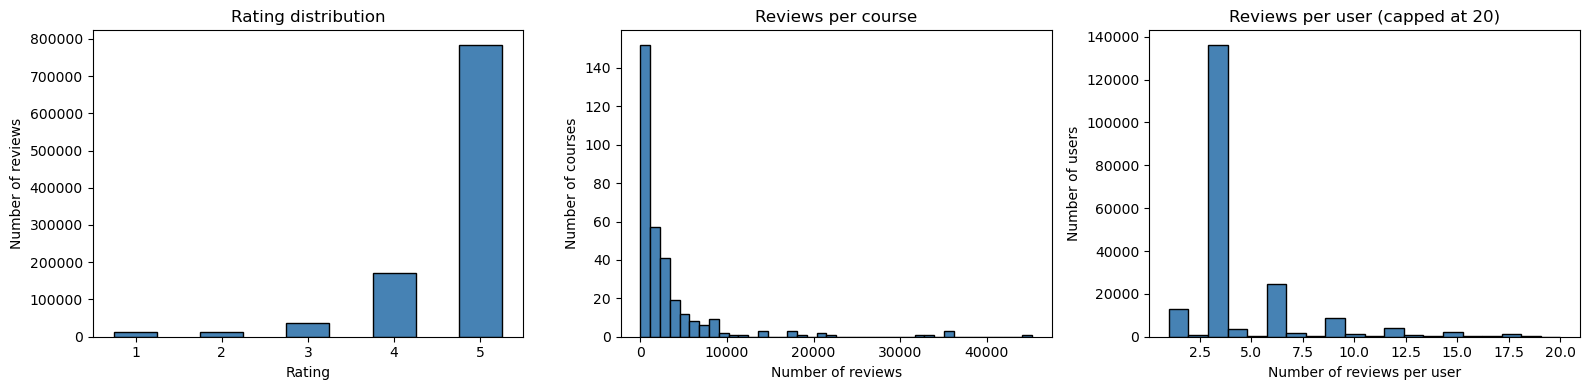

In [4]:
# Visualise the data distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Rating distribution
reviews['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xticklabels([1, 2, 3, 4, 5], rotation=0)

# 2. Reviews per course (how popular is each course)
reviews.groupby('course_id').size().plot(
    kind='hist', bins=40, ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Reviews per course')
axes[1].set_xlabel('Number of reviews')
axes[1].set_ylabel('Number of courses')

# 3. Reviews per user (capped at 20 because most users review only 1-2 courses)
reviews_per_user = reviews.groupby('reviewers').size()
reviews_per_user[reviews_per_user <= 20].plot(
    kind='hist', bins=20, ax=axes[2], color='steelblue', edgecolor='black'
)
axes[2].set_title('Reviews per user (capped at 20)')
axes[2].set_xlabel('Number of reviews per user')
axes[2].set_ylabel('Number of users')

plt.tight_layout()
plt.show()

> The charts confirm the 5-star skew, the long-tail of course popularity, and the high concentration of users with only a few reviews.

## Feature engineering: popularity statistics
For each course I calculate the average rating and review count, then combine them into a single popularity score. This score drives the popularity baseline model.

In [5]:
# Calculate average rating and review count per course
course_stats = reviews.groupby('course_id').agg(
    avg_rating=('rating', 'mean'),
    n_reviews=('rating', 'count')
).reset_index()

# Merge these stats into the courses table
courses = courses.merge(course_stats, on='course_id', how='left')

# Drop courses with no reviews (can't recommend what nobody rated)
courses = courses.dropna(subset=['n_reviews']).copy()

# Popularity score = average rating boosted by log of review count
# Using log so a course with 50,000 reviews doesn't outweigh a course with 5,000 too much
courses['popularity_score'] = courses['avg_rating'] * np.log1p(courses['n_reviews'])

print(f"Courses with at least one rating: {len(courses)}")
print(f"\nTop 5 most popular courses:")
print(courses.nlargest(5, 'popularity_score')[
    ['name', 'institution', 'avg_rating', 'n_reviews', 'popularity_score']
].to_string(index=False))

Courses with at least one rating: 324

Top 5 most popular courses:
                                                                          name                        institution  avg_rating  n_reviews  popularity_score
                                                        Python Data Structures             University of Michigan    4.846629    33546.0         50.505275
                                             Neural Networks and Deep Learning                    DeepLearning.AI    4.775888    35750.0         50.072004
                                                Technical Support Fundamentals                             Google    4.776183    35319.0         50.017164
Learning How to Learn: Powerful mental tools to help you master tough subjects University of California San Diego    4.802139    32265.0         49.854695
                                                              Machine Learning                Stanford University    4.750522    35895.0         49.825289


## Popularity baseline model
A simple function that returns the top-K most popular courses. Same recommendation for every user.

In [6]:
# Popularity baseline: same top-K recommendations for every user
def recommend_popular(top_k=10):
    return courses.nlargest(top_k, 'popularity_score')[
        ['name', 'institution', 'avg_rating', 'n_reviews']
    ]

print("Top 10 courses by popularity baseline:")
print(recommend_popular(10).to_string(index=False))

Top 10 courses by popularity baseline:
                                                                                  name                        institution  avg_rating  n_reviews
                                                                Python Data Structures             University of Michigan    4.846629    33546.0
                                                     Neural Networks and Deep Learning                    DeepLearning.AI    4.775888    35750.0
                                                        Technical Support Fundamentals                             Google    4.776183    35319.0
        Learning How to Learn: Powerful mental tools to help you master tough subjects University of California San Diego    4.802139    32265.0
                                                                      Machine Learning                Stanford University    4.750522    35895.0
                               Programming for Everybody (Getting Started with Python)     

## Prepare the data for the Surprise library

In [7]:
# Convert the ratings into the format Surprise expects: (user, item, rating)
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(reviews[['reviewers', 'course_id', 'rating']], reader)

## Train the collaborative filtering model
Split the data 80/20, then train an SVD model on the training set.

In [8]:
# Split into 80% training and 20% testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the SVD model: 50 latent factors, 20 training rounds (epochs)
model = SVD(n_factors=50, n_epochs=20, random_state=42)
model.fit(trainset)

print(f"Training set: {trainset.n_ratings} ratings")
print(f"Test set: {len(testset)} ratings")
print("Model trained")

Training set: 815728 ratings
Test set: 203932 ratings
Model trained


## Evaluate the CF model on the test set
Use the trained model to predict ratings for the 20% held-out test ratings, then measure error with RMSE and MAE.

In [9]:
from surprise import accuracy

# Predict ratings for the held-out test set
predictions = model.test(testset)

# Calculate Root Mean Square Error (lower is better)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.4806
MAE:  0.3115


## Personalised recommendations for a sample user
Pick a real active user, predict ratings for every course they have not yet rated, then return the 10 with the highest predictions.

In [10]:
# Pick the most active real user (skip 'By Deleted' anonymous placeholders)
real_users = reviews[~reviews['reviewers'].str.contains('Deleted', case=False, na=False)]
sample_user = real_users['reviewers'].value_counts().index[0]
rated_by_user = set(reviews[reviews['reviewers'] == sample_user]['course_id'].values)

# Predict ratings for all courses this user has NOT rated
all_course_ids = courses['course_id'].unique()
unrated = [c for c in all_course_ids if c not in rated_by_user]

cf_predictions = []
for course_id in unrated:
    pred = model.predict(sample_user, course_id)
    cf_predictions.append((course_id, pred.est))

# Sort by predicted rating and take top 10
cf_predictions.sort(key=lambda x: x[1], reverse=True)
top_10 = cf_predictions[:10]

# Look up the course names
top_10_df = pd.DataFrame(top_10, columns=['course_id', 'predicted_rating'])
top_10_df = top_10_df.merge(courses[['course_id', 'name', 'institution']], on='course_id')

print(f"Sample user: {sample_user}")
print(f"Courses already rated: {len(rated_by_user)}")
print(f"\nTop 10 personalised recommendations from the CF model:\n")
print(top_10_df[['name', 'institution', 'predicted_rating']].to_string(index=False))

Sample user: By Muhammad A
Courses already rated: 91

Top 10 personalised recommendations from the CF model:

                                                                                        name                                institution  predicted_rating
                                    Become a CBRS Certified Professional Installer by Google                  Google - Spectrum Sharing                 5
                                                        Primeros Auxilios Psicológicos (PAP)          Universitat Autònoma de Barcelona                 5
                                            Mathematics for Machine Learning: Linear Algebra                    Imperial College London                 5
                                        System Administration and IT Infrastructure Services                                     Google                 5
                                                      Introduction to Social Media Marketing                            

## Compare both models on the same test set

In [11]:
# Popularity baseline: predict each course's average rating
def popularity_predict(course_id):
    avg = courses.loc[courses['course_id'] == course_id, 'avg_rating']
    return avg.values[0] if len(avg) > 0 else reviews['rating'].mean()

# Generate popularity predictions for the test set
pop_actual_pairs = [(p.r_ui, popularity_predict(p.iid)) for p in predictions]

# Calculate RMSE and MAE for the popularity baseline
pop_rmse = np.sqrt(np.mean([(t - p)**2 for t, p in pop_actual_pairs]))
pop_mae = np.mean([abs(t - p) for t, p in pop_actual_pairs])

# Build a comparison table
comparison = pd.DataFrame({
    'Model': ['Popularity Baseline', 'Collaborative Filtering (SVD)'],
    'RMSE': [pop_rmse, rmse],
    'MAE': [pop_mae, mae]
})

print(comparison.to_string(index=False))

rmse_improvement = (pop_rmse - rmse) / pop_rmse * 100
mae_improvement = (pop_mae - mae) / pop_mae * 100
print(f"\nCF improvement over popularity baseline:")
print(f"  RMSE: {rmse_improvement:.1f}% lower")
print(f"  MAE:  {mae_improvement:.1f}% lower")

                        Model     RMSE      MAE
          Popularity Baseline 0.698111 0.470573
Collaborative Filtering (SVD) 0.480559 0.311483

CF improvement over popularity baseline:
  RMSE: 31.2% lower
  MAE:  33.8% lower


## Visualise the comparison
Bar chart of RMSE and MAE for both models.

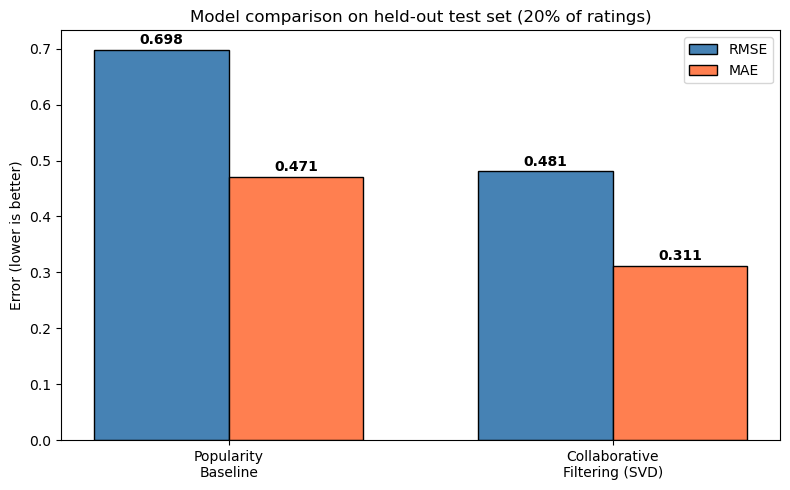

In [12]:
# Bar chart comparing the two models on RMSE and MAE
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Popularity\nBaseline', 'Collaborative\nFiltering (SVD)']
rmse_values = [pop_rmse, rmse]
mae_values = [pop_mae, mae]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue', edgecolor='black')
ax.bar(x + width/2, mae_values, width, label='MAE', color='coral', edgecolor='black')

ax.set_ylabel('Error (lower is better)')
ax.set_title('Model comparison on held-out test set (20% of ratings)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for i, v in enumerate(rmse_values):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
for i, v in enumerate(mae_values):
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
import pickle

# Save the trained CF model for the hybrid model and the web application
with open('cf_model_courses.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the courses table with its popularity statistics
courses.to_csv('coursera_courses_with_popularity.csv', index=False)

print("Saved: cf_model_courses.pkl")
print("Saved: coursera_courses_with_popularity.csv")

Saved: cf_model_courses.pkl
Saved: coursera_courses_with_popularity.csv
